Libraries loaded.
Test size       : 22,011
Classes         : ['가구/인테리어', '도서', '디지털/가전', '생활/건강', '스포츠/레저', '식품', '여가/생활편의', '출산/육아', '패션의류', '패션잡화', '화장품/미용']
TF-IDF LR probs : (22011, 11)
KoBERT probs    : (22011, 11)
STAGE 1 — FULL MODEL COMPARISON (including KoBERT)
                     model  accuracy  macro_f1  weighted_f1 train_time_sec
    TF-IDF + LR (Baseline)    0.8569    0.8566       0.8566           33.1
          TF-IDF + XGBoost    0.8066    0.8075       0.8075         4209.4
    TF-IDF + Random Forest    0.7887    0.7879       0.7879          311.7
KoBERT (klue/roberta-base)    0.8726    0.8724       0.8724           None

Saved → results/stage1_results_all.csv
Core functions defined: compute_scs / majority_vote / confidence_weighted_vote
[TF-IDF + LR    | Size= 5]  MV=0.9560  CWV=0.9720
[KoBERT         | Size= 5]  MV=0.9640  CWV=0.9720
[TF-IDF + LR    | Size=10]  MV=0.9940  CWV=0.9960
[KoBERT         | Size=10]  MV=0.9860  CWV=0.9920
[TF-IDF + LR    | Size=20]  MV=1.00

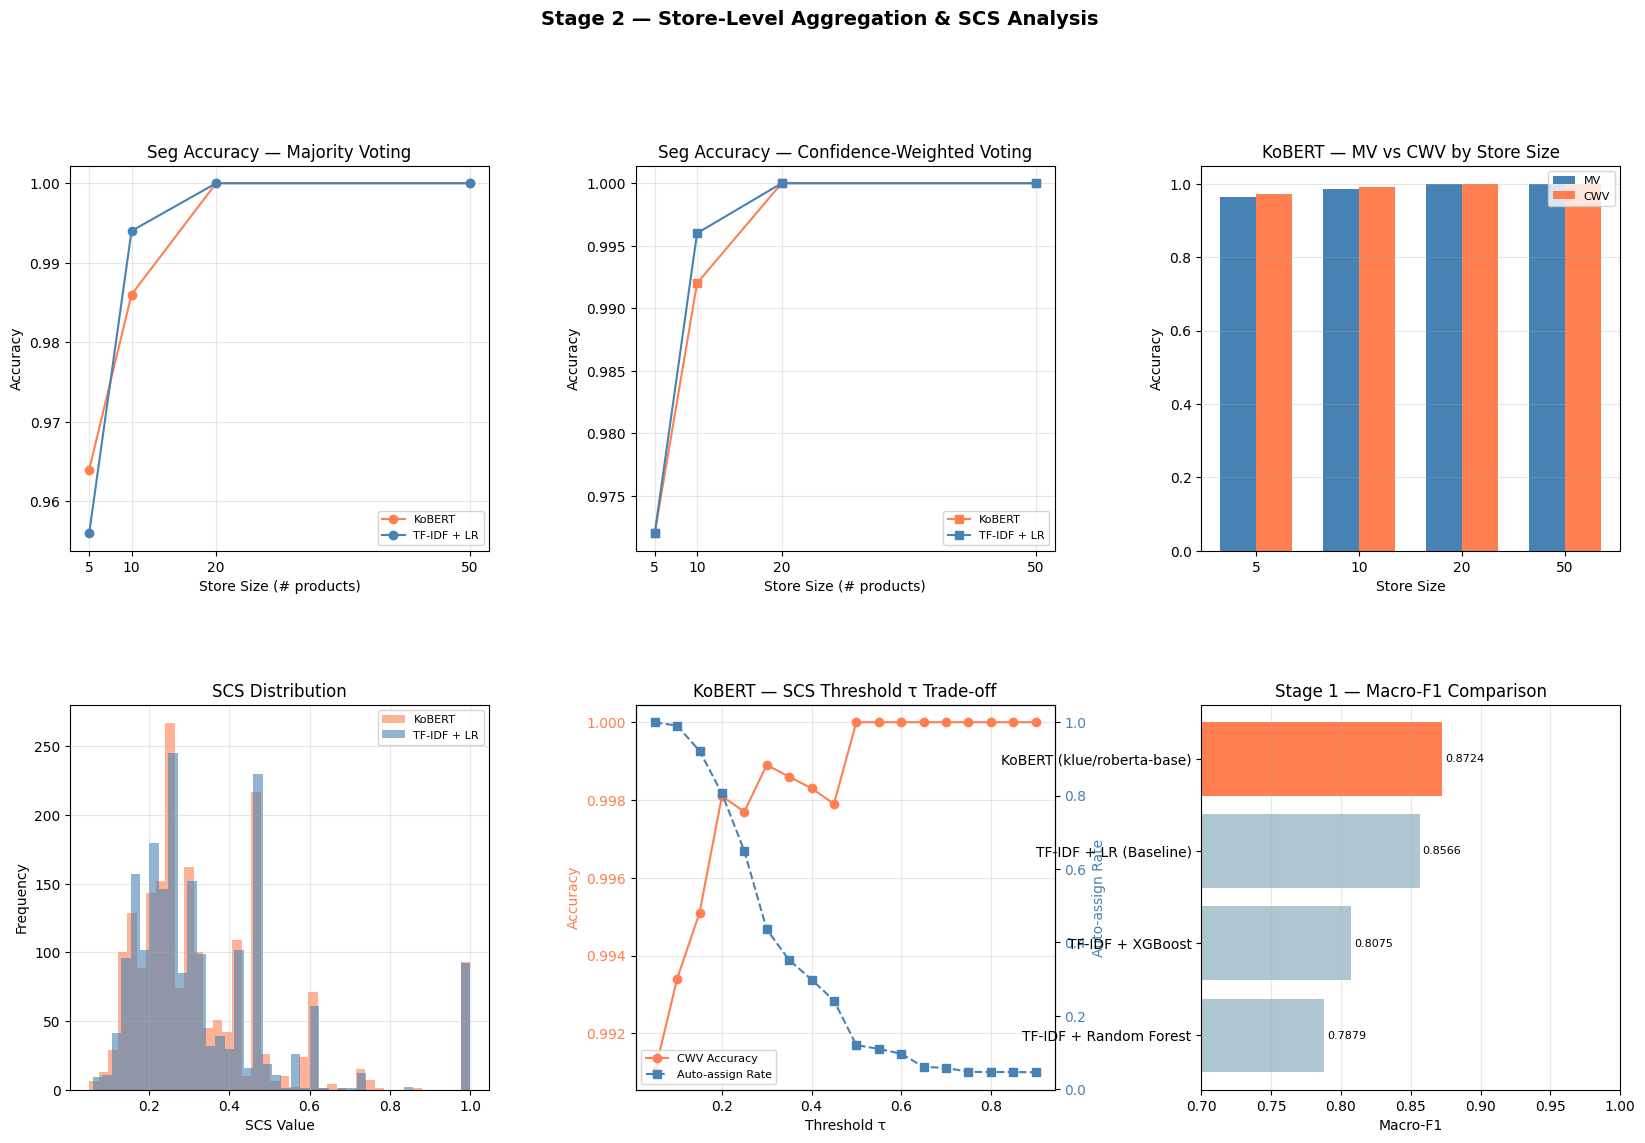

Saved → results/stage2_figures.png

STAGE 2 SUMMARY
    backend  store_size  n_stores  acc_majority_voting  acc_confidence_weighted  avg_scs
TF-IDF + LR           5       500                0.956                    0.972   0.4141
     KoBERT           5       500                0.964                    0.972   0.4045
TF-IDF + LR          10       500                0.994                    0.996   0.3476
     KoBERT          10       500                0.986                    0.992   0.3419
TF-IDF + LR          20       500                1.000                    1.000   0.2964
     KoBERT          20       500                1.000                    1.000   0.3217
TF-IDF + LR          50       500                1.000                    1.000   0.2823
     KoBERT          50       500                1.000                    1.000   0.3017

SCS formula : SCS = (n_dominant / N) × 1 / (1 + H)
  H = Shannon Entropy of predicted category distribution

Best backend for Stage 2: KoBERT (hig

In [4]:
# =============================================================
# 03_stage2_aggregation_scs.ipynb
# Stage 2 — Store-Level Aggregation & SCS (Seg Confidence Score)
# -------------------------------------------------------------
# Compares two classification backends:
#   - TF-IDF + LR  (local, models/best_tfidf_model.pkl)
#   - KoBERT       (Colab, data/kobert_test_probs.npy)
#
# For each backend:
#   1. Majority Voting vs. Confidence-Weighted Voting
#   2. SCS computation & threshold τ analysis
#   3. Store-size sensitivity simulation
#
# Input  : data/test.csv
#          data/label_encoder.pkl
#          models/best_tfidf_model.pkl
#          data/kobert_test_probs.npy
#          data/kobert_test_preds.npy
#          results/stage1_results.csv
#          results/kobert_test_result.csv
# Output : results/stage2_voting_comparison.csv
#          results/stage2_scs_threshold.csv
#          results/stage2_store_simulation.csv
#          results/stage2_figures.png
# =============================================================

# ── Cell 1: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import entropy as scipy_entropy
from collections import Counter
import os

os.makedirs('results', exist_ok=True)
print("Libraries loaded.")


# ── Cell 2: Load Data & Models ───────────────────────────────
test_df = pd.read_csv('data/test.csv')

with open('data/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
y_true      = test_df['label'].values

# ── TF-IDF + LR ──────────────────────────────────────────────
with open('models/best_tfidf_model.pkl', 'rb') as f:
    saved = pickle.load(f)
vec, clf = saved['vectorizer'], saved['model']

X_test_tfidf    = vec.transform(test_df['prod_name'].values)
probs_lr        = clf.predict_proba(X_test_tfidf)
preds_lr        = np.argmax(probs_lr, axis=1)

# ── KoBERT (from Colab) ───────────────────────────────────────
probs_kb = np.load('data/kobert_test_probs.npy')
preds_kb = np.load('data/kobert_test_preds.npy').astype(int)

print(f"Test size       : {len(test_df):,}")
print(f"Classes         : {le.classes_.tolist()}")
print(f"TF-IDF LR probs : {probs_lr.shape}")
print(f"KoBERT probs    : {probs_kb.shape}")


# ── Cell 3: Stage 1 Summary (combined) ──────────────────────
# Merge local stage1 results with KoBERT result from Colab
from sklearn.metrics import accuracy_score, f1_score

stage1_local = pd.read_csv('results/stage1_results.csv')
stage1_kb    = pd.read_csv('results/kobert_test_result.csv')

# Align columns
stage1_kb_row = pd.DataFrame([{
    'model'          : stage1_kb['model'].iloc[0],
    'accuracy'       : stage1_kb['accuracy'].iloc[0],
    'macro_f1'       : stage1_kb['macro_f1'].iloc[0],
    'weighted_f1'    : stage1_kb['weighted_f1'].iloc[0],
    'train_time_sec' : None
}])

stage1_all = pd.concat([stage1_local, stage1_kb_row], ignore_index=True)
stage1_all.to_csv('results/stage1_results_all.csv', index=False)

print("=" * 65)
print("STAGE 1 — FULL MODEL COMPARISON (including KoBERT)")
print("=" * 65)
print(stage1_all.to_string(index=False))
print("\nSaved → results/stage1_results_all.csv")


# ── Cell 4: Core Functions ───────────────────────────────────
def compute_scs(pred_labels: np.ndarray, n_classes: int) -> float:
    """
    Seg Confidence Score (SCS) — proposed metric.
    SCS = (n_dominant / N) × 1 / (1 + H)
    H : Shannon Entropy of predicted category distribution (bits)
    SCS → 1 : single-category store  (high confidence)
    SCS → 0 : dispersed multi-category store (flag for manual review)
    """
    n      = len(pred_labels)
    counts = np.bincount(pred_labels, minlength=n_classes)
    n_dom  = counts.max()
    p      = counts / n
    H      = scipy_entropy(p + 1e-10, base=2)
    return round(float((n_dom / n) * (1.0 / (1.0 + H))), 6)

def majority_vote(pred_labels: np.ndarray) -> int:
    return Counter(pred_labels).most_common(1)[0][0]

def confidence_weighted_vote(pred_labels: np.ndarray,
                              pred_probs: np.ndarray) -> int:
    return int(np.argmax(pred_probs.sum(axis=0)))

print("Core functions defined: compute_scs / majority_vote / confidence_weighted_vote")


# ── Cell 5: Store Simulation ─────────────────────────────────
"""
Realistic virtual store construction:
  Each store has a dominant category (true Seg) + minor spillover.

  Dominant ratio sampled from Uniform(0.6, 1.0):
    - 60%~100% of products belong to the dominant category
    - Remaining products sampled uniformly from OTHER categories

  This reflects real e-commerce sellers who focus on one category
  but occasionally list products from adjacent categories.

  Store sizes tested : 5, 10, 20, 50 products
  Stores per condition: 500
"""
N_STORES    = 500
STORE_SIZES = [5, 10, 20, 50]
RANDOM_SEED = 42
rng         = np.random.default_rng(RANDOM_SEED)

# Attach predictions/probs to test_df
test_df = test_df.copy()
test_df['true'] = y_true

for c in range(NUM_CLASSES):
    test_df[f'prob_lr_{c}'] = probs_lr[:, c]
    test_df[f'prob_kb_{c}'] = probs_kb[:, c]

test_df['pred_lr'] = preds_lr
test_df['pred_kb'] = preds_kb

# Pre-index products by true label for fast sampling
label_indices = {
    cls: test_df.index[test_df['true'] == cls].tolist()
    for cls in range(NUM_CLASSES)
}

BACKENDS = {
    'TF-IDF + LR': ('pred_lr', [f'prob_lr_{c}' for c in range(NUM_CLASSES)]),
    'KoBERT'     : ('pred_kb', [f'prob_kb_{c}' for c in range(NUM_CLASSES)]),
}

sim_records    = []
detail_records = []

for store_size in STORE_SIZES:
    for backend_name, (pred_col, prob_cols) in BACKENDS.items():
        correct_mv  = 0
        correct_cwv = 0

        for _ in range(N_STORES):
            # 1. Pick dominant category (true Seg) randomly
            dom_cat = rng.integers(0, NUM_CLASSES)

            # 2. Sample dominant ratio from Uniform(0.6, 1.0)
            dom_ratio = rng.uniform(0.6, 1.0)
            n_dom     = max(1, int(round(store_size * dom_ratio)))
            n_other   = store_size - n_dom

            # 3. Sample dominant products
            dom_idx = rng.choice(label_indices[dom_cat],
                                 size=min(n_dom, len(label_indices[dom_cat])),
                                 replace=False).tolist()

            # 4. Sample other-category products
            other_cats = [c for c in range(NUM_CLASSES) if c != dom_cat]
            other_idx  = []
            if n_other > 0:
                pool = []
                for oc in other_cats:
                    pool.extend(label_indices[oc])
                other_idx = rng.choice(pool,
                                       size=min(n_other, len(pool)),
                                       replace=False).tolist()

            # 5. Combine & fetch products
            all_idx  = dom_idx + other_idx
            products = test_df.loc[all_idx]

            pred_labels = products[pred_col].values.astype(int)
            pred_probs_ = products[prob_cols].values

            seg_mv  = majority_vote(pred_labels)
            seg_cwv = confidence_weighted_vote(pred_labels, pred_probs_)
            scs_val = compute_scs(pred_labels, NUM_CLASSES)

            c_mv  = int(seg_mv  == dom_cat)
            c_cwv = int(seg_cwv == dom_cat)
            correct_mv  += c_mv
            correct_cwv += c_cwv

            detail_records.append({
                'backend'    : backend_name,
                'store_size' : store_size,
                'dom_cat'    : dom_cat,
                'dom_ratio'  : round(float(n_dom / store_size), 3),
                'seg_mv'     : seg_mv,
                'seg_cwv'    : seg_cwv,
                'scs'        : scs_val,
                'correct_mv' : c_mv,
                'correct_cwv': c_cwv
            })

        sim_records.append({
            'backend'                : backend_name,
            'store_size'             : store_size,
            'n_stores'               : N_STORES,
            'acc_majority_voting'    : round(correct_mv  / N_STORES, 4),
            'acc_confidence_weighted': round(correct_cwv / N_STORES, 4),
            'avg_scs'                : round(
                np.mean([r['scs'] for r in detail_records
                         if r['backend'] == backend_name
                         and r['store_size'] == store_size]), 4)
        })

        print(f"[{backend_name:<14} | Size={store_size:2d}]  "
              f"MV={correct_mv/N_STORES:.4f}  "
              f"CWV={correct_cwv/N_STORES:.4f}")

sim_df    = pd.DataFrame(sim_records)
detail_df = pd.DataFrame(detail_records)

sim_df.to_csv('results/stage2_voting_comparison.csv',   index=False)
detail_df.to_csv('results/stage2_store_simulation.csv', index=False)
print("\nSaved → results/stage2_voting_comparison.csv")
print("Saved → results/stage2_store_simulation.csv")


# ── Cell 6: SCS Threshold Analysis ──────────────────────────
tau_values = np.arange(0.05, 0.95, 0.05)
thresh_records = []

for backend_name in BACKENDS:
    sub = detail_df[detail_df['backend'] == backend_name]
    for tau in tau_values:
        auto = sub[sub['scs'] >= tau]
        if len(auto) == 0:
            continue
        thresh_records.append({
            'backend'    : backend_name,
            'tau'        : round(float(tau), 2),
            'auto_rate'  : round(len(auto) / len(sub), 4),
            'acc_cwv'    : round(auto['correct_cwv'].mean(), 4),
            'n_auto'     : len(auto),
            'n_manual'   : len(sub) - len(auto)
        })

thresh_df = pd.DataFrame(thresh_records)
thresh_df.to_csv('results/stage2_scs_threshold.csv', index=False)
print("Saved → results/stage2_scs_threshold.csv")

# Optimal τ per backend (acc maximized at auto_rate >= 80%)
print("\nOptimal τ per backend (auto_rate ≥ 80%):")
for backend_name in BACKENDS:
    sub = thresh_df[(thresh_df['backend'] == backend_name) &
                    (thresh_df['auto_rate'] >= 0.80)]
    if len(sub) > 0:
        opt = sub.loc[sub['acc_cwv'].idxmax()]
        print(f"  [{backend_name}]  τ={opt['tau']}  "
              f"Auto-rate={opt['auto_rate']:.2%}  "
              f"CWV-Acc={opt['acc_cwv']:.4f}")


# ── Cell 7: Visualization ────────────────────────────────────
COLORS = {'TF-IDF + LR': 'steelblue', 'KoBERT': 'coral'}

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# (1) Seg accuracy by store size — MV
ax1 = fig.add_subplot(gs[0, 0])
for bk, grp in sim_df.groupby('backend'):
    ax1.plot(grp['store_size'], grp['acc_majority_voting'],
             marker='o', label=bk, color=COLORS[bk])
ax1.set_title('Seg Accuracy — Majority Voting')
ax1.set_xlabel('Store Size (# products)')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(STORE_SIZES)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# (2) Seg accuracy by store size — CWV
ax2 = fig.add_subplot(gs[0, 1])
for bk, grp in sim_df.groupby('backend'):
    ax2.plot(grp['store_size'], grp['acc_confidence_weighted'],
             marker='s', label=bk, color=COLORS[bk])
ax2.set_title('Seg Accuracy — Confidence-Weighted Voting')
ax2.set_xlabel('Store Size (# products)')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(STORE_SIZES)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# (3) MV vs CWV gap (KoBERT only)
ax3 = fig.add_subplot(gs[0, 2])
kb = sim_df[sim_df['backend'] == 'KoBERT']
x  = np.arange(len(STORE_SIZES))
w  = 0.35
ax3.bar(x - w/2, kb['acc_majority_voting'],    width=w, label='MV',  color='steelblue')
ax3.bar(x + w/2, kb['acc_confidence_weighted'], width=w, label='CWV', color='coral')
ax3.set_title('KoBERT — MV vs CWV by Store Size')
ax3.set_xlabel('Store Size')
ax3.set_ylabel('Accuracy')
ax3.set_xticks(x)
ax3.set_xticklabels(STORE_SIZES)
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3, axis='y')

# (4) SCS distribution per backend
ax4 = fig.add_subplot(gs[1, 0])
for bk, grp in detail_df.groupby('backend'):
    ax4.hist(grp['scs'], bins=40, alpha=0.6, label=bk, color=COLORS[bk])
ax4.set_title('SCS Distribution')
ax4.set_xlabel('SCS Value')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# (5) τ threshold — acc vs auto-rate (KoBERT)
ax5 = fig.add_subplot(gs[1, 1])
kb_t = thresh_df[thresh_df['backend'] == 'KoBERT']
ax5.plot(kb_t['tau'], kb_t['acc_cwv'],   marker='o',
         color='coral',     label='CWV Accuracy')
ax5b = ax5.twinx()
ax5b.plot(kb_t['tau'], kb_t['auto_rate'], marker='s', linestyle='--',
          color='steelblue', label='Auto-assign Rate')
ax5.set_title('KoBERT — SCS Threshold τ Trade-off')
ax5.set_xlabel('Threshold τ')
ax5.set_ylabel('Accuracy',        color='coral')
ax5b.set_ylabel('Auto-assign Rate', color='steelblue')
ax5.tick_params(axis='y', labelcolor='coral')
ax5b.tick_params(axis='y', labelcolor='steelblue')
lines = ax5.get_lines() + ax5b.get_lines()
ax5.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='lower left')
ax5.grid(alpha=0.3)

# (6) Stage 1 model comparison bar chart
ax6 = fig.add_subplot(gs[1, 2])
s1  = stage1_all.sort_values('macro_f1')
bars = ax6.barh(s1['model'], s1['macro_f1'],
                color=['#aec6cf','#aec6cf','#aec6cf','coral'])
ax6.set_title('Stage 1 — Macro-F1 Comparison')
ax6.set_xlabel('Macro-F1')
ax6.set_xlim(0.7, 1.0)
for bar, val in zip(bars, s1['macro_f1']):
    ax6.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
ax6.grid(alpha=0.3, axis='x')

plt.suptitle('Stage 2 — Store-Level Aggregation & SCS Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('results/stage2_figures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/stage2_figures.png")


# ── Cell 8: Summary ──────────────────────────────────────────
print("\n" + "=" * 65)
print("STAGE 2 SUMMARY")
print("=" * 65)
print(sim_df.to_string(index=False))
print(f"\nSCS formula : SCS = (n_dominant / N) × 1 / (1 + H)")
print(f"  H = Shannon Entropy of predicted category distribution")
print(f"\nBest backend for Stage 2: KoBERT (higher product-level F1 → better CWV)")
print("=" * 65)
print("Next → 04_stage4_llm_notice.ipynb")